# EPILEPSY
We have a dataset that contains labels on the last row. We want to simply plot and statistically analyze our data for this lecture


## Inizializzo il workspace

In [3]:
import pandas as pd 
import matplotlib.pyplot as plt
from pathlib import Path

In [4]:

BASE_DIR = Path.cwd()   
file_path = BASE_DIR / "data" / "EEG-data.xlsx" 
print(f"Controlla che questo sia l'indirizzo corretto, altrimenti non ti leggerà il file una volta caricato: \n{file_path}")
print("Creo il dataframe ...")
data = pd.read_excel(file_path)
print(f"Dataframe importato. I tuoi dati hanno dimensioni {data.shape}")
data.head()


Controlla che questo sia l'indirizzo corretto, altrimenti non ti leggerà il file una volta caricato: 
/Users/goli/Progetti/Healthcare/data/EEG-data.xlsx
Creo il dataframe ...
Dataframe importato. I tuoi dati hanno dimensioni (500, 4096)


,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X4086,X4087,X4088,X4089,X4090,X4091,X4092,X4093,X4094,y
0,0,-56,-50,-64,-91,-135,-140,-134,-114,-115,...,-37,-43,-63,-82,-114,-138,-159,-172,-180,5
1,1,14,25,31,36,33,33,27,27,21,...,-45,-32,-6,-7,-2,-20,-34,-40,-40,5
2,2,-159,-176,-174,-145,-101,-45,0,29,15,...,-40,-25,14,56,73,48,-12,-62,-100,4
3,3,34,31,29,19,16,12,3,-1,-5,...,-34,-33,-29,-22,-18,-14,-10,-9,0,3
4,4,44,50,46,43,43,46,45,40,36,...,4,5,6,6,2,1,0,-1,-4,2


## Creazione dei due dataframe
Nel primo abbiamo solo label = 2, nel secondo label = 3

In [5]:
# creo il dataframe 2, senza la prima colonna e l'ultima che contiene solo le labels 
data_2 = data.loc[data['y']== 2].copy()
data_2 = data_2.drop(columns=["Unnamed: 0","y"])

# creo il dataframe 3, senza la prima colonna e l'ultima che contiene solo le labels 
data_3 = data.loc[data['y']== 3].copy()
data_3 = data_3.drop(columns=["Unnamed: 0","y"])

print(f"Dataframe 2 di dimensioni: {data_2.shape}")
print(f"Dataframe 3 di dimensioni: {data_3.shape}")

Dataframe 2 di dimensioni: (100, 4094)
Dataframe 3 di dimensioni: (100, 4094)


                     Paziente 2: Statistiche 
Minimo:  -273 		Massimo:  105 		Media:  -32.22 


                     Paziente 3: Statistiche 
Minimo:  -117 		Massimo:  68 		Media:  -3.94


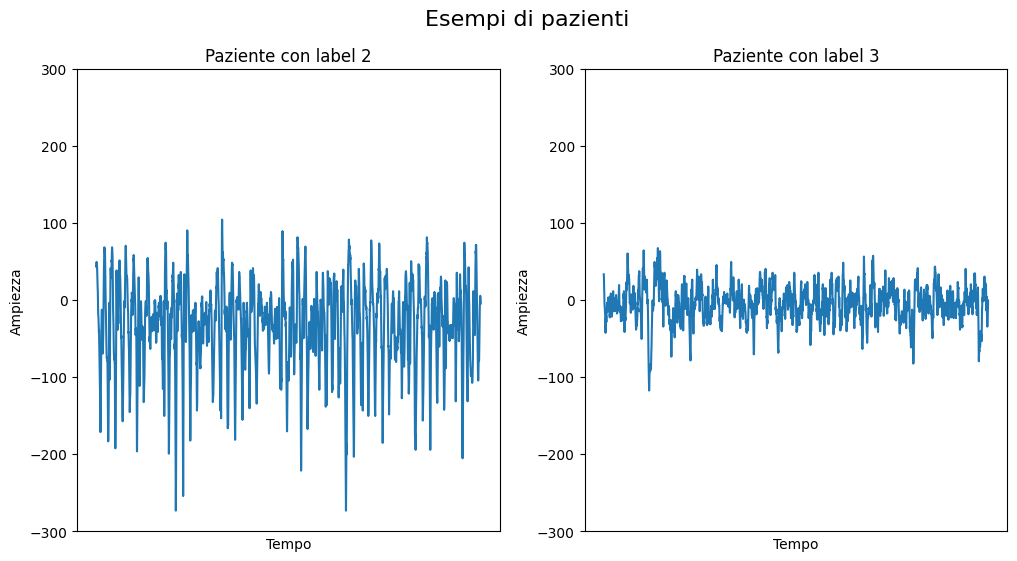

In [6]:
row_2 = data_2.iloc[0]
row_3 = data_3.iloc[0]
print('                     Paziente 2: Statistiche \nMinimo: ', row_2.min(), '\t\tMassimo: ', row_2.max(), '\t\tMedia: ', round(row_2.mean(),ndigits=2),'\n\n')
print('                     Paziente 3: Statistiche \nMinimo: ', row_3.min(), '\t\tMassimo: ', row_3.max(), '\t\tMedia: ',round(row_3.mean(),ndigits=2))
fig = plt.figure(figsize = (12,6))
fig.suptitle('Esempi di pazienti', fontsize = 16)
ax1 = plt.subplot(121)
plt.ylim(-300, 300)
plt.title("Paziente con label 2")
plt.xticks([])
plt.xlabel("Tempo")
plt.ylabel("Ampiezza")
plt.plot(row_2)


ax2 = plt.subplot(122, sharey = ax1)
plt.title("Paziente con label 3")
plt.xticks([])
plt.xlabel("Tempo")
plt.ylabel("Ampiezza")
plt.plot(row_3)
plt.show()

TEST TRAIN SPLIT

In [7]:
train_2 = data_2[0:79]
test_2= data_2[80:99]
train_3 = data_3[0:79]
test_3= data_3[80:99]

train = pd.concat([train_2, train_3])
test = pd.concat([test_2, test_3])
train_2.head()


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X4085,X4086,X4087,X4088,X4089,X4090,X4091,X4092,X4093,X4094
4,44,50,46,43,43,46,45,40,36,31,...,-4,4,5,6,6,2,1,0,-1,-4
11,60,47,38,29,28,30,28,30,36,51,...,668,705,646,546,450,366,296,248,209,177
12,-23,-31,-34,-40,-43,-49,-54,-53,-48,-37,...,14,19,20,20,20,24,24,23,26,27
18,-6,-5,-10,-12,-8,-7,-8,-6,-1,9,...,45,49,52,59,69,75,75,76,68,55
23,-7,-12,-14,-21,-31,-42,-48,-47,-53,-49,...,-19,-19,-13,-10,-10,-9,-4,6,6,7


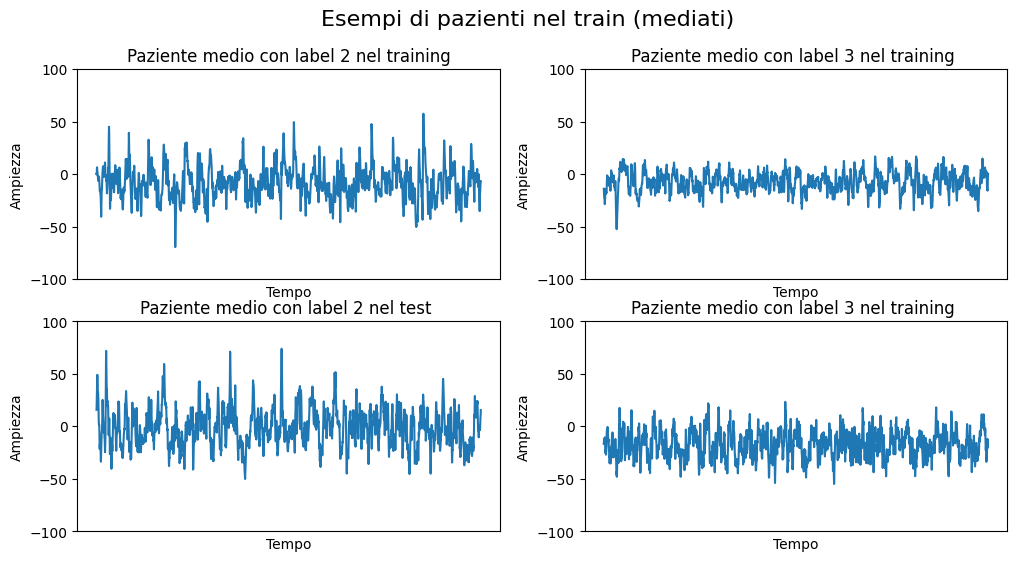

In [14]:
fig = plt.figure(figsize = (12,6))
fig.suptitle('Esempi di pazienti nel train (mediati)', fontsize = 16)
ax1 = plt.subplot(221)
plt.ylim(-100, 100)
plt.title("Paziente medio con label 2 nel training")
plt.xticks([])
plt.xlabel("Tempo")
plt.ylabel("Ampiezza")
plt.plot(train_2.mean())


ax2 = plt.subplot(222, sharey = ax1)
plt.title("Paziente medio con label 3 nel training ")
plt.xticks([])
plt.xlabel("Tempo")
plt.ylabel("Ampiezza")
plt.plot(train_3.mean())

ax3 = plt.subplot(223, sharey = ax1)
plt.title("Paziente medio con label 2 nel test ")
plt.xticks([])
plt.xlabel("Tempo")
plt.ylabel("Ampiezza")
plt.plot(test_2.mean())

ax4 = plt.subplot(224, sharey = ax1)
plt.title("Paziente medio con label 3 nel training ")
plt.xticks([])
plt.xlabel("Tempo")
plt.ylabel("Ampiezza")
plt.plot(test_3.mean())


In [10]:
# ma che è? 
mean_2 = []
min_2 = []
max_2 = []
for i in range(data_2.shape[0]):
    mean_2.append(float(data_2.iloc[i].mean()))
    min_2.append(float(data_2.iloc[i].min()))
    max_2.append(float(data_2.iloc[i].max()))

